# AUSTO AUTOMOBILE CASE STUDY

---




### UNDERSTANDING THE BUSINESS CASE:

Austo motor company is a leading car manufacturing company specialized in manufacturing suv, sedan and hatchback models. They want to understand the marketing performance of these models with respect to various attributes in their sales data. In order to understand the deeper insights of customers and their purchase preferences, we as a data scientist are expected to analyse the data and extract the valuable insights from it. These insights should help marketing team in understanding which variables or factors are affecting the sales performances and accordingly focus on the said approaches to attain desired results.

VARIABLES:
Data Description

1. Age(in yr): Age of the customer
2. Gender: Male or Female(Binary variable)
3. Profession: The Job of the customer(Binary variable)
4. Marital_status: Married and single(Binary variable)
5. Education: Graduate and Post Graduate(Binary variable)
6. No_of_Dependents: The No of dependents which include children, elderly parents etc
7. Personal_loan: "Yes" or "No" (Binary variable)
8. House_loan: "Yes" or "No" (Binary variable)
9. Partner_working: "Yes" or "No" (Binary variable)
10. Salary: The customer's salary or income.
11. Partner_salary: The salary or income the customers partner
12. Total_salary: The added salary of the customer and their partner
13. Price: The price of a the car
14. Make: The type of automobile - SUV,Sedan,Hatchback


### IMPORTING THE LIBRARIES

Python libraries used: Numpy, Pandas, Matplotlib, Seaborn

In [70]:
# IMPORTING THE NECESSARY LIBRARIES FOR DATA ANALYSIS:

import numpy as np
import pandas as pd

# IMPORTING LIBRARIES TO HELP WITH DATA VISUALIZATION:

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid') # setting the style for visualization

In [71]:
from google.colab import drive # importing/linking the google drive with google colab.
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### DATA OVERVIEW : 1.1. IMPORTING THE DATA AND DEFINING THE VARIABLES:

Initially we analyze the data based on couple of below steps:
*   First we open the google drive in google colab and open or load the path of the file from the drive to G-Colab
*   Next we find out the brief of the dataset as how and what it is stored in various variable, their count and check for missing or unusual information too.
*   We observe the statistical information of the data and how it is spread thus analysing the details of it further more.

In [72]:
path="/content/drive/My Drive/austo_automobile.csv" # Loading the dataset 'austo_automobile.csv' as csv file into google colab.
data = pd.read_csv(path) # Reading the dataset

data.head() # This function helps view the first five rows of the data. T is transpose of the data

,Age,Gender,Profession,Marital_status,Education,No_of_Dependents,Personal_loan,House_loan,Partner_working,Salary,Partner_salary,Total_salary,Price,Make
0,53,Male,Business,Married,Post Graduate,4,No,No,Yes,99300,70700.0,170000,61000,SUV
1,53,Femal,Salaried,Married,Post Graduate,4,Yes,No,Yes,95500,70300.0,165800,61000,SUV
2,53,Female,Salaried,Married,Post Graduate,3,No,No,Yes,97300,60700.0,158000,57000,SUV
3,53,Female,Salaried,Married,Graduate,2,Yes,No,Yes,72500,70300.0,142800,61000,SUV
4,53,Male,Salaried,Married,Post Graduate,3,No,No,Yes,79700,60200.0,139900,57000,SUV


Inferences:
*   The dataset contains the information about the customers who purchased the cars at various prices and various make of the cars
*   Certain details about the customer gender, type of education, profession, marital status, them taking loan, their salary are also available which present the customer choices or his details.
*   These can be observed to understand customer choices or purchase patterns.

In [73]:
data.tail().T # It helps view the last five rows of the data

,1576,1577,1578,1579,1580
Age,22,22,22,22,22
Gender,Male,Male,Male,Male,Male
Profession,Salaried,Business,Business,Business,Salaried
Marital_status,Single,Married,Single,Married,Married
Education,Graduate,Graduate,Graduate,Graduate,Graduate
No_of_Dependents,2,4,2,3,4
Personal_loan,No,No,No,Yes,No
House_loan,Yes,No,Yes,Yes,No
Partner_working,No,No,No,No,No
Salary,33300,32000,32900,32200,31600


In [74]:
data.shape # It gives the rows and columns of the data

(1581, 14)

*   There are totally 1581 rows and 14 columns in the data


In [75]:
data.info()
# It gives the brief of data like data types, Columns, Range of columns like total no of rows and columns.
# This helps understand and identify the missed data and identify the data type if it is wrong. Thus correcting the data.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1581 entries, 0 to 1580
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1581 non-null   int64  
 1   Gender            1528 non-null   object 
 2   Profession        1581 non-null   object 
 3   Marital_status    1581 non-null   object 
 4   Education         1581 non-null   object 
 5   No_of_Dependents  1581 non-null   int64  
 6   Personal_loan     1581 non-null   object 
 7   House_loan        1581 non-null   object 
 8   Partner_working   1581 non-null   object 
 9   Salary            1581 non-null   int64  
 10  Partner_salary    1475 non-null   float64
 11  Total_salary      1581 non-null   int64  
 12  Price             1581 non-null   int64  
 13  Make              1581 non-null   object 
dtypes: float64(1), int64(5), object(8)
memory usage: 173.1+ KB


CATEGORICAL VARIABLES IN THE DATA:

Gender, Profession, Marital status, Education, Personal loan, House loan, Partner working, Make

NUMERICAL VARIABLES IN THE DATA:

Age, No of dependants, Salary, Partner salary, Total salary, Price

*   We see data irregularities in the above info function where gender and partner salary count is less than the total count. It might infer that there are missing values which need to be corrected.




### DATA CLEANING BY IMPUTING THE MISSING VALUES

In [76]:
print(data.isnull().sum())  # Check for missing values in columns

Age                   0
Gender               53
Profession            0
Marital_status        0
Education             0
No_of_Dependents      0
Personal_loan         0
House_loan            0
Partner_working       0
Salary                0
Partner_salary      106
Total_salary          0
Price                 0
Make                  0
dtype: int64




*   We see Gender and Partner_salary variables have missing values which can be treated by imputing them with the median values of the said data.
*   We can also impute the missing values with mean for normal data and median for skewed data.



In [77]:
data['Gender'].fillna('Unknown', inplace=True) # fillna() is used to replace unknown values
data['Partner_salary'].fillna(data['Partner_salary'].median(), inplace=True) # Imputation of rows with missing values

data['Gender'] = data['Gender'].replace(['Femal', 'Femle', 'Unknown'], 'Female') # replacing values with correct spelled names

data.info() # Checking the data again to identify if the missing values are corrected

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1581 entries, 0 to 1580
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1581 non-null   int64  
 1   Gender            1581 non-null   object 
 2   Profession        1581 non-null   object 
 3   Marital_status    1581 non-null   object 
 4   Education         1581 non-null   object 
 5   No_of_Dependents  1581 non-null   int64  
 6   Personal_loan     1581 non-null   object 
 7   House_loan        1581 non-null   object 
 8   Partner_working   1581 non-null   object 
 9   Salary            1581 non-null   int64  
 10  Partner_salary    1581 non-null   float64
 11  Total_salary      1581 non-null   int64  
 12  Price             1581 non-null   int64  
 13  Make              1581 non-null   object 
dtypes: float64(1), int64(5), object(8)
memory usage: 173.1+ KB


<ipython-input-77-15e8b6249024>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Gender'].fillna('Unknown', inplace=True) # fillna() is used to replace unknown values
<ipython-input-77-15e8b6249024>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[



*   Data is now corrected and we see partner salary and gender count is same as the total data.




### STATISTICAL ANALYSIS OF DATA

In [78]:
# It describes the total numerical values in the dataset and give quick statistical summary.
# It also gives a summary of data like min, max, mean,standard deviation   and quartiles,count, unique, top values and frequently appearing values.
data.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,1581.0,NaN,NaN,NaN,31.922201,8.425978,22.0,25.0,29.0,38.0,54.0
Gender,1581,2,Male,1199,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Profession,1581,2,Salaried,896,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Marital_status,1581,2,Married,1443,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education,1581,2,Post Graduate,985,NaN,NaN,NaN,NaN,NaN,NaN,NaN
No_of_Dependents,1581.0,NaN,NaN,NaN,2.457938,0.943483,0.0,2.0,2.0,3.0,4.0
Personal_loan,1581,2,Yes,792,NaN,NaN,NaN,NaN,NaN,NaN,NaN
House_loan,1581,2,No,1054,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Partner_working,1581,2,Yes,868,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Salary,1581.0,NaN,NaN,NaN,60392.220114,14674.825044,30000.0,51900.0,59500.0,71800.0,99300.0




*   Customers with versatile age group starting from 22 years to 54 years have purchased the cars.
*   Nearly 50% of the customers are under age 30 which indicates that younger crowd are purchasing more compared to older age customers.
*   Salaries range from 30000 to 99000 with an average salary of the customers is around 60000 where as the average price of the car is 31000.


### TREATING OUTLIERS

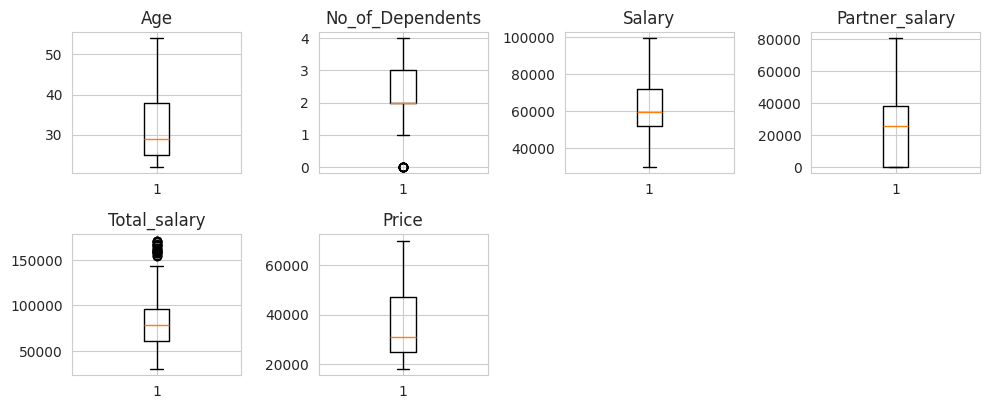

In [79]:
numeric_data = ['Age', 'No_of_Dependents', 'Salary', 'Partner_salary', 'Total_salary', 'Price'] # Numerical columns are grouped into a list called numeric_data

plt.figure(figsize=(10,8))

for i,variable in enumerate(numeric_data):
  plt.subplot(4,4, i + 1)
  plt.boxplot(data[variable], whis = 1.5) # Plotting a box plot of all the numeric data to understand or identify the specific outliers
  plt.title(variable)

plt.tight_layout()
plt.show()



*   Two columns named No_of_Dependents and Total_salary have outliers which need to be addressed.
*   Age, Partner_salary and Price are heavily right skewed data with median around 30000. Which indicates most of the data is towards the lower values.



In [80]:
# Defining the Q1 and Q3 to address the Interquartile range.
# This helps define the outliers and impute the nearest lowerbound and upperbound values to them.
# This helps in bringing the outliers within the data range so that they dont affect the other datapoints.

Q1 = data[numeric_data].quantile(0.25)
Q3 = data[numeric_data].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

((data[numeric_data]<lower_bound) | (data[numeric_data]>upper_bound)).sum()/data.shape[0]*100
# Calculating the percentage of these columns to understand the outlier percentage in the given data.


,0
Age,0.000000
No_of_Dependents,1.265022
Salary,0.000000
Partner_salary,0.000000
Total_salary,1.707780
Price,0.000000


*   As infered No_of_Dependents has 1.26% outliers and total salary has 1.7% outliers.
*   If these outliers are treated the data can be better interpreted with accuracy and reliable dataset.
*   We can also see better graphs or visualizations.

In [81]:
def treat_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1 # Defining the interquartile range

  # Outliers are the values outside the range of innerbound and outer bound.
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[col] = np.clip(df[col], lower_bound, upper_bound)
    return df

In [82]:
# Applying the treat_outliers function to the specific columns and imputing or treating the data for better visuals.

data = treat_outliers(data, 'No_of_Dependents')
data = treat_outliers(data, 'Total_salary')
data = treat_outliers(data, 'Price')

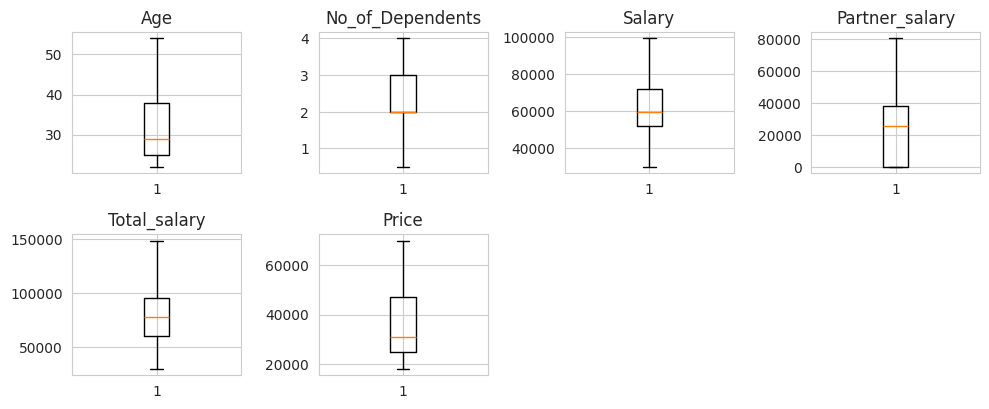

In [83]:
# Plotting the numeric data again to check if the outliers are removed

plt.figure(figsize=(10,8))

for i,variable in enumerate(numeric_data):
  plt.subplot(4,4, i + 1)
  plt.boxplot(data[variable], whis = 1.5)
  plt.title(variable)

plt.tight_layout()
plt.show()

*   We see that the outliers are removed and data is clean now. Box plots show normal distributed values.
*   After the outliers are treated total salary is now evenly distributed which shows a less influence on mean or median.
*   Similarly after treating outliers in age, we could clearly interpret that data is right skewed.





### Understanding the numerical variables and their correlation with one or more variable:


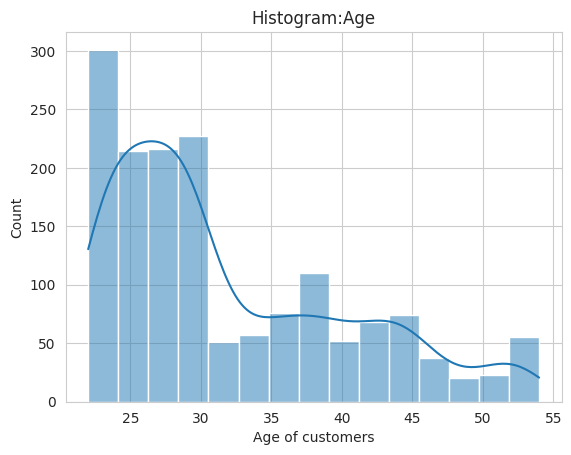

In [84]:
# Understanding and visualizing single numerical variable: Age
sns.histplot(data = data, x = 'Age', kde = True) # kde is kernel density estimation which shows how the data is distributed in the dataset.
plt.title('Histogram:Age')
plt.xlabel('Age of customers')
plt.show()

*   The above histogram shows the plot of age of customers and the count of distribution of data.
*   Here we see data is right skewed with most of the customers belong to the age group of 25-30 years.





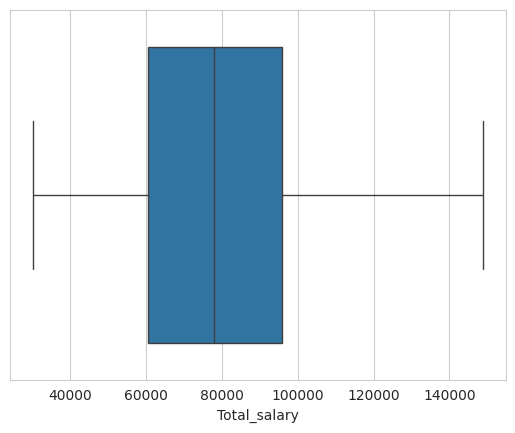

In [85]:
sns.boxplot(data = data, x='Total_salary')
plt.show()



*   The above box plot explains the total salary distribution with the count.
*   This plot explains the median is closer to Q1 which explains most of the customers are having salaries less than median.



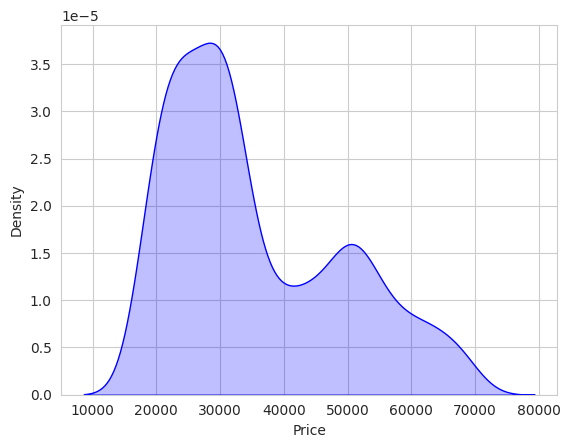

In [86]:
# Understanding and visualizing single numerical variable: Price
sns.kdeplot(data=data['Price'], color="blue", fill=True)
plt.show()

*   The above KDE plot - kernel density estimation, explains that the data is right skewed and probability density distribution of the price.
*   Area under the curve indicates the density of these prices in different ranges.
*   Data has two clusters indicating the distribution of price under two ranges which is 20000 to 30000 and 45000 to 55000.
*   Most of the customers purchased the cars at around the median price of 20000 to 30000.

In [87]:
data[['Age','No_of_Dependents','Salary','Partner_salary','Total_salary','Price']].corr()

,Age,No_of_Dependents,Salary,Partner_salary,Total_salary,Price
Age,1.000000,-0.194020,0.616899,0.121187,0.452844,0.797831
No_of_Dependents,-0.194020,1.000000,-0.032646,0.117950,0.083573,-0.141375
Salary,0.616899,-0.032646,1.000000,0.065348,0.638625,0.409920
Partner_salary,0.121187,0.117950,0.065348,1.000000,0.765147,0.161136
Total_salary,0.452844,0.083573,0.638625,0.765147,1.000000,0.359651
Price,0.797831,-0.141375,0.409920,0.161136,0.359651,1.000000


*   This code calculates the correlation matrix for numerical data. A correlation matrix means understanding the correlation between all the numerical variables and how one variable affects the other.
*   Values range from -1 to +1. When both variables show high values, its understood that they are strongly correlated. And if one variable show less values and the other shows higher values then weak correlation exist.

Key Takeaways
- Higher salaries seem positively correlated with purchasing higher-priced automobiles.
- Partner_salary contributes significantly to Total_salary with a 77% correlation.
- More dependents are leading to purchase lower-priced cars thus explaining a negative correlation effect.
- Age has a weak correlation with automobile price, suggesting spending is not heavily age-dependent.

We can visualize these inferences with a heatmap to make the patterns clearer.




<Axes: >

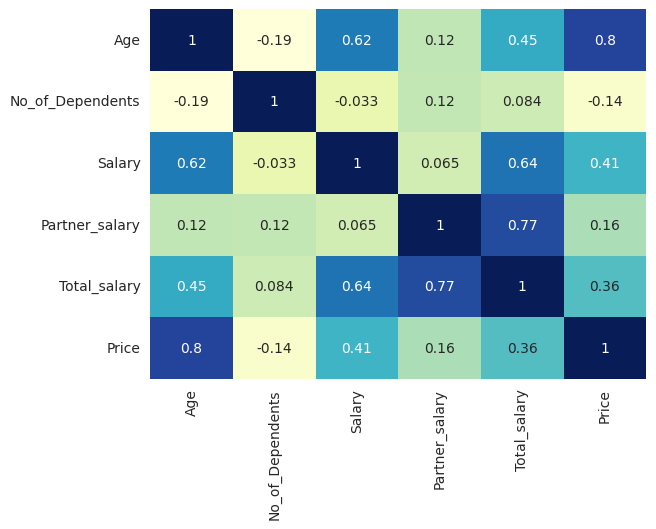

In [88]:
sns.heatmap(data=data[['Age','No_of_Dependents','Salary','Partner_salary', 'Total_salary','Price']].corr(),annot=True, cmap='YlGnBu',cbar=False)

Heatmap visualizes relationships between variables in a matrix format.

*   Salary and total salary show strong positive correlation as total salary is the sum of salary and partner salary
*   Similarly partner salary correlate well with total salary
*   No of dependents and price show negative correlation which means customers having more no of dependents tend to buy lesser priced cars
*   Age and price show a zero or no correlation.





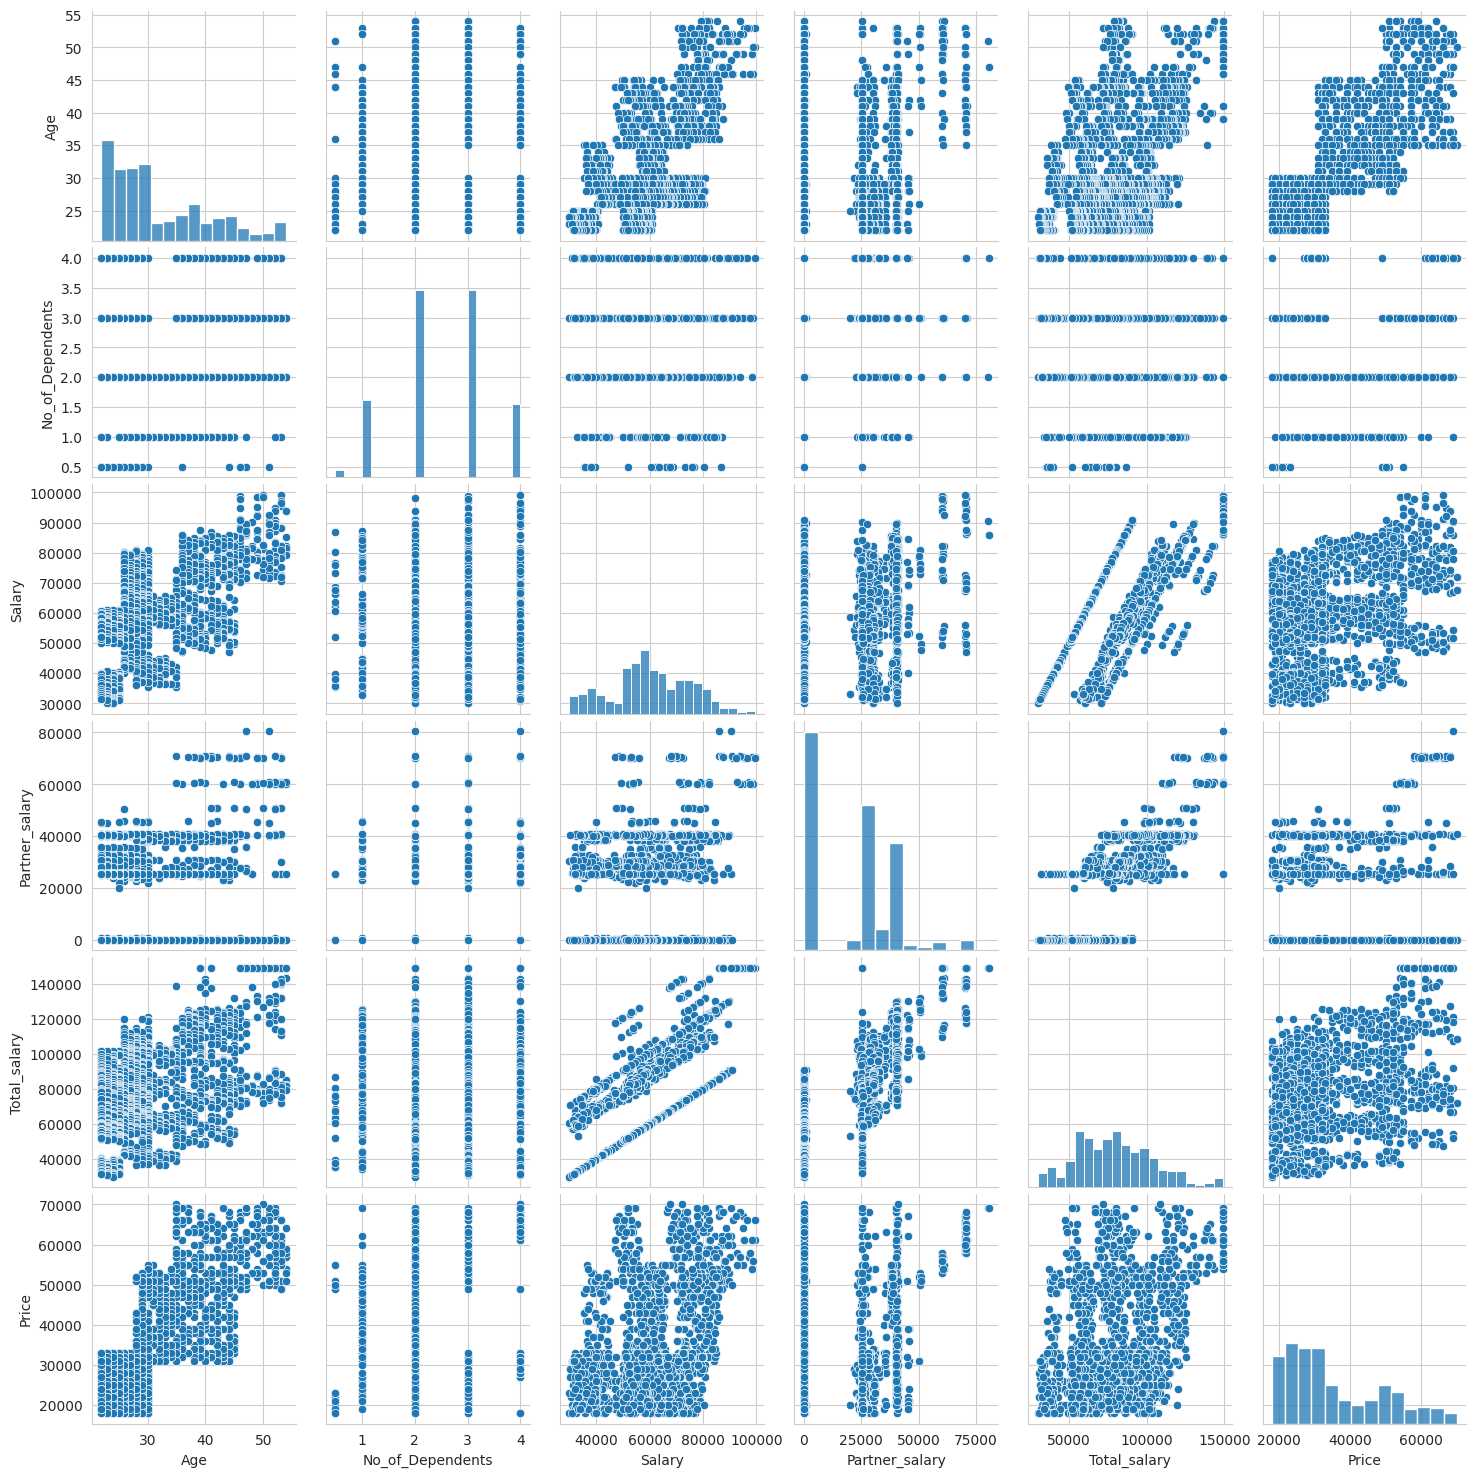

In [89]:
sns.pairplot(data=data[['Age','No_of_Dependents','Salary','Partner_salary', 'Total_salary','Price']])


*   We get multiple scatter plots showing pairwise relationships between these variables.
*   Diagonal plots show univariate distributions of variables like the histograms.
*   It includes scatter plots for individual variable distribution
*   I used it to understand the pattern and trend of the data which is positively and diagonally moving upwards for most of the variables like Age, Salary
*   Variables like no of dependents and partner salary dont show any upward diagonal trend or growth however prices No of dependents increases when compared with other variables.









### Analyzing the Categorical variables: Gender, Profession, Marital_status,Education, Personal_loan, House_loan, Partner_Working, Make


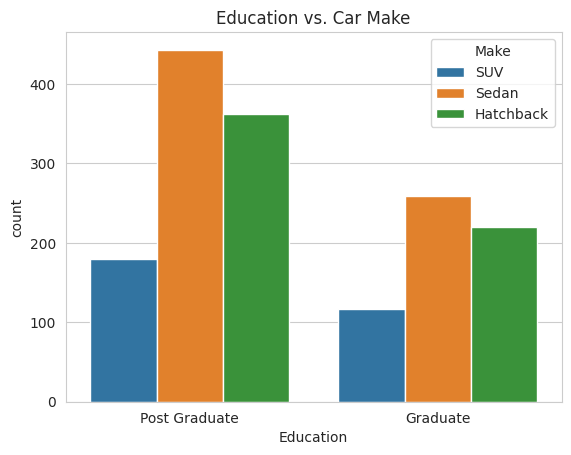

In [90]:
# Using a countplot to analyse the categorical variables : Education and make
sns.countplot(data = data, x = 'Education', hue = 'Make') # Shows the count of each categorical bin using bars.
plt.xlabel('Education')
plt.title('Education vs. Car Make')
plt.show()



*   This graph infers that the post graduate customers tend to purchase more of high priced cars compared to graduate customers
*   Most of the post graduates prefer sedan cars and then hatchback cars.
*   Most of the graduates prefer sedan cars.
*   If one looks at SUV sales, sale numbers are nearby same for both graduate and postgraduate customers

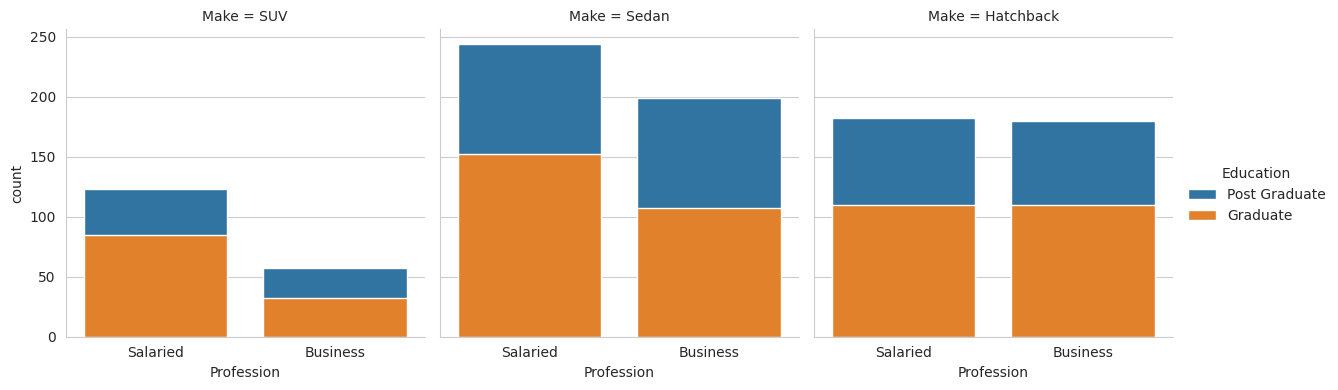

In [91]:
# Use FacetGrid for creating multiple plots by using subsets based on 'Make' and 'Education'
h = sns.FacetGrid(data=data, col='Make', hue='Education', col_wrap=3, height=4)
h.map(sns.countplot, 'Profession', order=data['Profession'].value_counts().index)
h.add_legend(title='Education')
plt.show()



*   The above facetgrid infers how profession varies across the make categories and education
*   A graudate and salaried customers prefer more of sedan cars
*   whereas graduates where they do business or job, both categories customers prefer sedan and hatchback cars equally.





### Analyzing the numerical variables and their correlation with categorical variables:

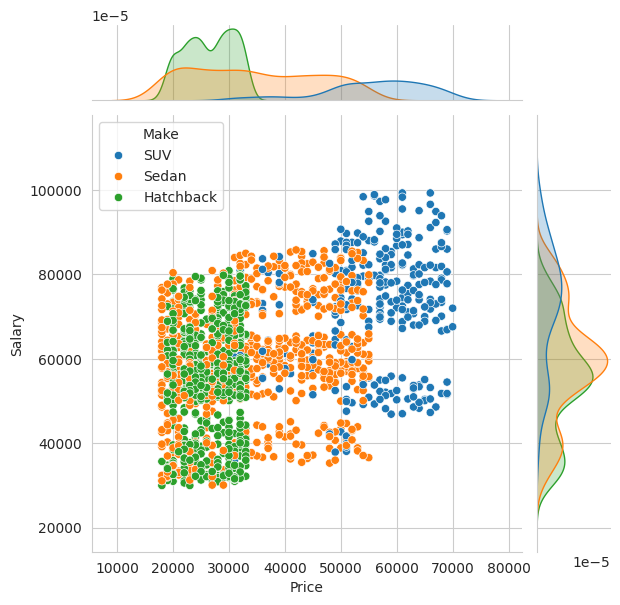

In [92]:
# Understanding the relationship between numerical variables and Categorical variable: Price vs Salary vs Make
# A jointplot shows the relationship between two variables price and salary thus combining scatterplot and line graph on the same graph.

sns.jointplot(data = data, x = 'Price', y = 'Salary', hue = 'Make')
plt.xlabel('Price')
plt.ylabel('Salary')
plt.show()



*   The scatterplot shows a diagonal upward spread of data indicating the individuals with higher salary tend to purchase higher prices cars.
*   SUV cars are purchased at higher prices and budget hatchbacks at lower price
*   There are no significant outliers in the data.
*   Compact clusters at mid range prices or salaries indicates that more purchases occur 30000 price and 60000 salary.





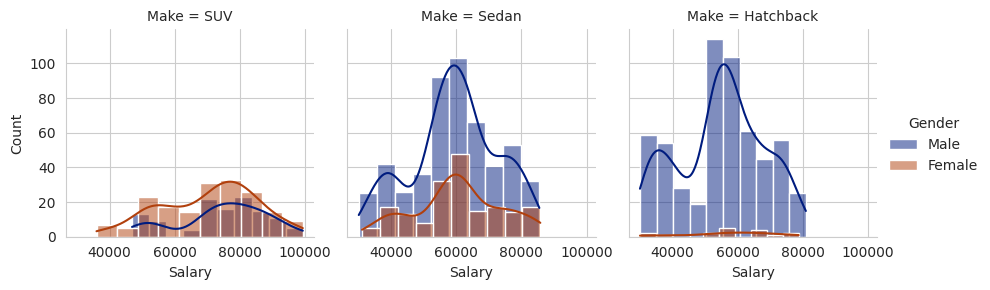

In [93]:
# Understanding the relationship between numerical variables and Categorical variable: Make & Gender Vs Salary using a Fecetgrid

g = sns.FacetGrid(data=data, col='Make', hue='Gender', palette = "dark")
g.map(sns.histplot, 'Salary', kde=True, bins=10)
g.add_legend(title='Gender')
plt.show()



*   Most of the males prefer to purchase hatchback cars whereas most of the females prefer to purchase sedan cars
* KDE density show two cluster of purchasers in sedan and hatchback models.
* A focus can be put on capturing the other low cluster datapoints and pitching the cars to these customers.



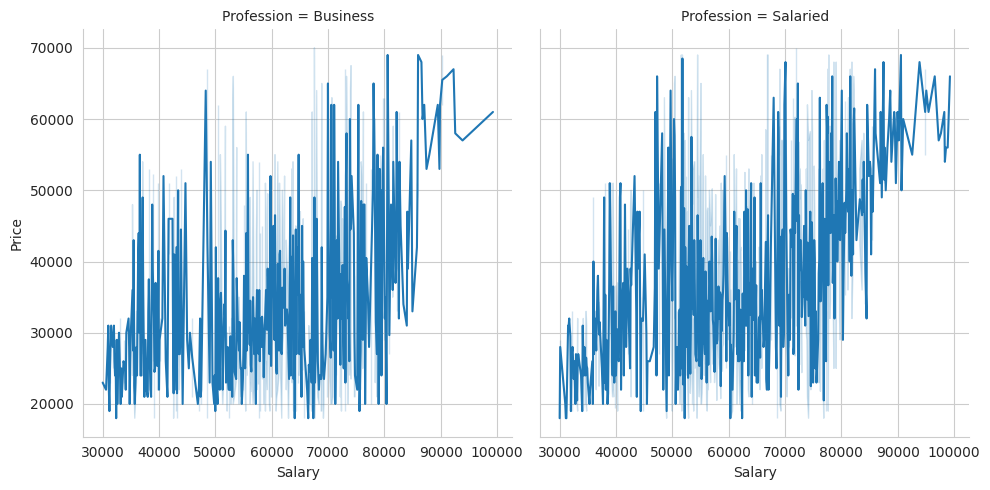

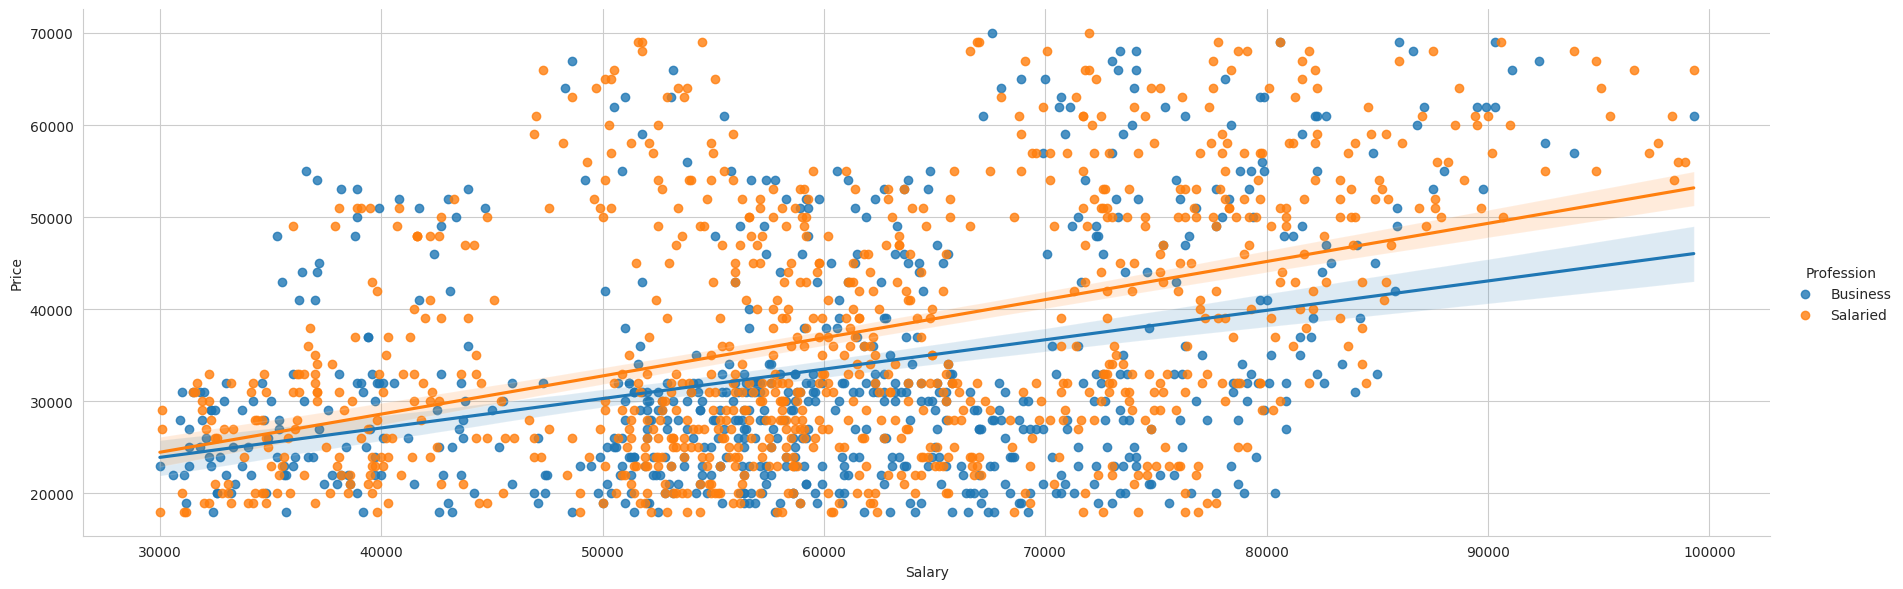

In [94]:
sns.relplot(data = data, x='Salary', y='Price', col='Profession',kind = 'line', col_wrap=2)  # Salary vs Price vs Profession
plt.show()
sns.lmplot(x='Salary', y='Price', hue='Profession', data = data, height = 6, aspect = 3)  # Salary vs Price
plt.show()

* This relational plot shows how Salary correlates with Price across different Professions, providing key insights into purchasing trends based on earnings.
* Plot shows a clear upward trend of the data which infers higher salaries or higher income in business mean purchase of higher priced cars
* Here a lmplot is used to create a scatterplot with a liner regression line to understand. The line if is flat, indicates both the variables are not impacted or correlate with each other.
* It shows a by default confidence interval of 95% which indicates data spread around the regression line.

###Understanding the rubric questions:

<ipython-input-95-33338b628cfd>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=suv_data, x = 'Gender', palette='viridis')


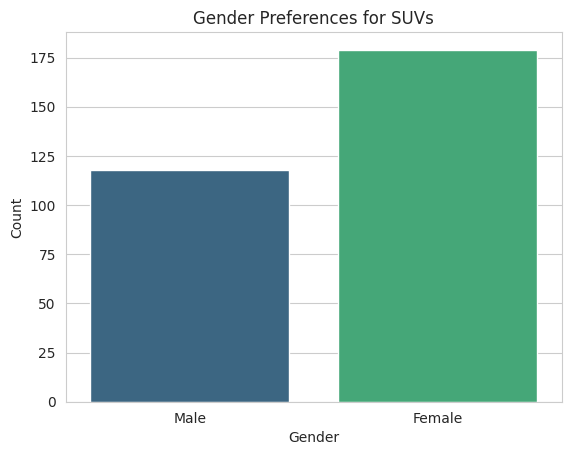

In [95]:
# 1. Do men tend to prefer SUVs more compared to women?

# Filtering data for SUVs only
suv_data = data[data['Make'] == 'SUV']

# Plotting gender counts for SUV preference
sns.countplot(data=suv_data, x = 'Gender', palette='viridis')
plt.title("Gender Preferences for SUVs")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()



*   Above graph infers that more females prefer to purchase SUV's compared to males




In [96]:
# 2. What is the likelihood of a salaried person buying a Sedan?

salaried_data = data[data['Profession'] == 'Salaried'] # filtering the salaried data from the profession variable
total_salaried = salaried_data.shape[0]  # Counting the total salaried individuals

# Calculating the salaried people's likelihood of buying a sedan or a suv.
# Likelihood can be calculated by filtering sedan and suv purchases by these salaried customers and counting the total by using shape function.

sedan_count = salaried_data[salaried_data['Make'] == 'Sedan'].shape[0]  # Count of Sedans bought
suv_count = salaried_data[salaried_data['Make'] == 'SUV'].shape[0]  # Count of SUV's bought

# After above steps of filtering and counting, we calculate the likelihood by proportion formula
sedan_likelihood = (sedan_count / total_salaried)*100  # Proportion
suv_likelihood = (suv_count / total_salaried)*100  # Proportion

print("The likelihood of a salaried person buying a Sedan is: ", sedan_likelihood)
print("The likelihood of a salaried person buying a SUV is: ", suv_likelihood)

The likelihood of a salaried person buying a Sedan is:  44.19642857142857
The likelihood of a salaried person buying a SUV is:  23.214285714285715


<ipython-input-97-3f47d51d2c74>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=Male_salaried, x='Make', palette='viridis')# Create the count plot using 'Make' column


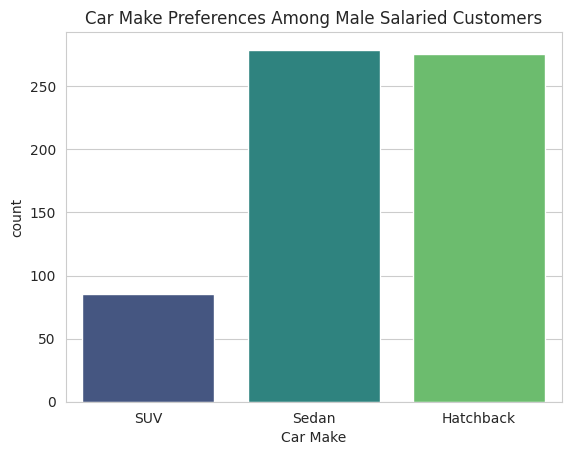

In [97]:
# 3. What evidence or data supports Sheldon Cooper's claim that a salaried male is an easier target for a SUV sale over a Sedan sale?

Male_salaried = data[(data['Gender'] == 'Male') & (data['Profession'] == 'Salaried')] # Filter the male salaried customers
sns.countplot(data=Male_salaried, x='Make', palette='viridis')# Create the count plot using 'Make' column
plt.xlabel('Car Make')
plt.title('Car Make Preferences Among Male Salaried Customers')
plt.show()

*   Above graph shows that most of the males are purchasing a sedan and hatchback cars compared to SUV cars.
*   However marketing team can pitch for the sale of SUV cars sale.
*   But when looking at the prices for Sedan and SUV cars, it should be understood regarding the affordability of these high priced SUV cars purchase by the salaried men.

<ipython-input-98-d736ee684c28>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = data, x='Gender', y='Price',palette='viridis')


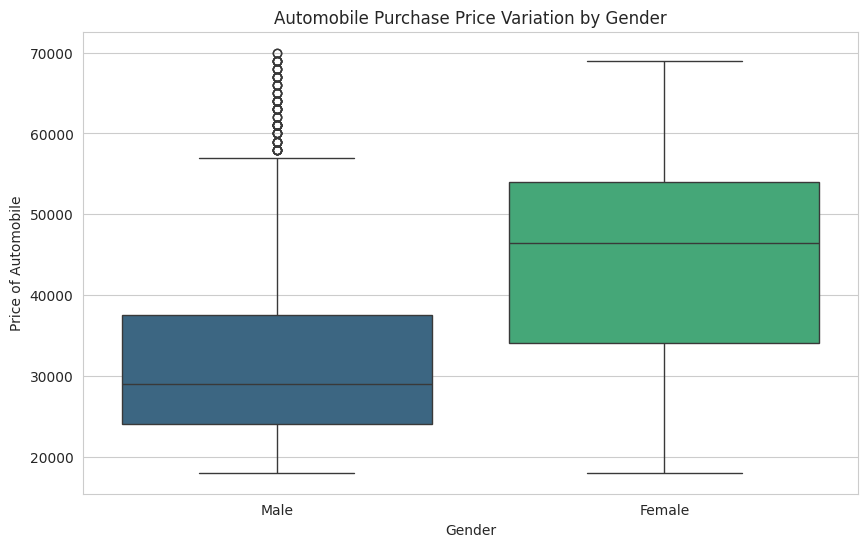

In [98]:
# 4. How does the the amount spent on purchasing automobiles vary by gender?

# Creating a box plot to compare the price distribution by gender
plt.figure(figsize=(10, 6))
sns.boxplot(data = data, x='Gender', y='Price',palette='viridis')
plt.title("Automobile Purchase Price Variation by Gender")
plt.xlabel("Gender")
plt.ylabel("Price of Automobile")
plt.show()



*   After observing the median values males purchase lower priced cars compared to females
*   Females show a taller box indicating a higher variability in automobile prices compared to males
*   Males show few outliers in purchasing higher priced cars, however treating them might disturb the data.
*   Also most of the partner's salary are not captured or is zero. Hence some of the data is shown as outliers for male variable. Capturing this data by client can show better output.







In [99]:
# 5. How much money was spent on purchasing automobiles by individuals who took a personal loan?
# Filtering individuals who took a personal loan
Personal_loan_takers = data[data['Personal_loan'] == 'Yes']

# Calculate total amount spent on automobile purchases
total_spent = Personal_loan_takers['Price'].sum()

print(f"Total amount spent by individuals who took a personal loan: {total_spent}")

Total amount spent by individuals who took a personal loan: 27290000


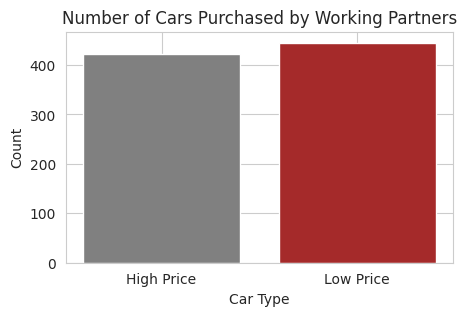

In [110]:
# 6. How does having a working partner influence the purchase of higher-priced cars?

higher_priced_cars = data[data['Price'] > data['Price'].median()] # Filtering the higher priced cars
lower_priced_cars = data[data['Price'] <= data['Price'].median()] # Filtering the lower priced cars

# Further filtering the working partners from the above high priced cars data.
partner_working_highcars = higher_priced_cars[higher_priced_cars['Partner_working'] == 'Yes']
partner_working_lowcars = lower_priced_cars[lower_priced_cars['Partner_working'] == 'Yes']

# Create counts for each car type
high_count = len(partner_working_highcars)
low_count = len(partner_working_lowcars)

# Data for plotting
categories = ['High Price', 'Low Price']
counts = [high_count, low_count]

# Bar plot
plt.figure(figsize=(5, 3))
plt.bar(categories, counts, color = ('grey','brown'))
plt.title("Number of Cars Purchased by Working Partners")
plt.xlabel("Car Type")
plt.ylabel("Count")
plt.show()


With the above graph it can be inferred that having a working partner does significantly affect the purchase of higher priced cars

### INFERENCES OR OBSERVATIONS

 Actionable Insights & Recommendations:
* Customers with versatile age group starting from 22 years to 54 years have purchased the cars.
* Nearly 50% of the customers are under age 30 which indicates that younger crowd are purchasing more compared to older age customers.
* Salaries range from 30000 to 99000 with an average salary of the customers is around 60000 whereas the average price of the car is 31000.
* Age, Partner salary and Price are heavily right skewed data with median around 30000. Which indicates most of the data is towards the lower values.
* Addressing the outliers help sort the data for better visualization and statistical analysis
* The histogram showing the plot of age of customers indicating most of the customers belong to the age group of 25-30 years.
* Most of the customers are having salaries less than median.
* The KDE plot - kernel density estimation, explains density distribution of the price having two clusters indicating the distribution of price under two ranges which is 20000 to 30000 and 45000 to 55000. Most of the customers purchased the cars at around the median price of 20000 to 30000.
* A correlation matrix of the numerical variables higher salaries seems positively correlated with purchasing higher-priced automobiles.
* Partner salary contributes significantly to Total salary with a 77% correlation.
* More dependents are leading to purchasing lower-priced cars thus explaining a negative correlation effect.
* Age has a weak correlation with automobile price, suggesting spending is not heavily age-dependent.
* Salary and total salary show strong positive correlation as total salary is the sum of salary and partner salary
* Similarly partner salary correlate well with total salary
* No of dependents and price show negative correlation which means customers having more no of dependents tend to buy lesser priced cars
* Age and price show a zero or no correlation.
* Variables like no of dependents and partner salary do not show any upward diagonal trend or growth however prices and no of dependents increases when compared with other variables.
*	post graduate customers tend to purchase more of high priced cars compared to graduate customers and most of the post graduates prefer sedan cars and then hatchback cars. If one looks at SUV sales, sale numbers are nearby same for both graduate and postgraduate customers.
* Most of the males prefer to purchase hatchback cars whereas most of the females prefer to purchase sedan cars. However while purchasing SUV’s, mostly women buy them compared to men.
* A focus can be put on capturing the other low cluster datapoints and pitching the cars to these customers.
* The likelihood of a salaried person buying a Sedan is:  44.1%
* having a working partner does significantly affect the purchase of higher priced cars.